In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

In [21]:
df = pd.read_csv('../data/clean/sentiment_v2.csv')

In [26]:
df.shape

(73549, 5)


SENTIMENT DISTRIBUTION
sentiment
positive    27234
negative    25875
neutral     20440
Name: count, dtype: int64
sentiment
positive    37.028376
negative    35.180628
neutral     27.790996
Name: proportion, dtype: float64


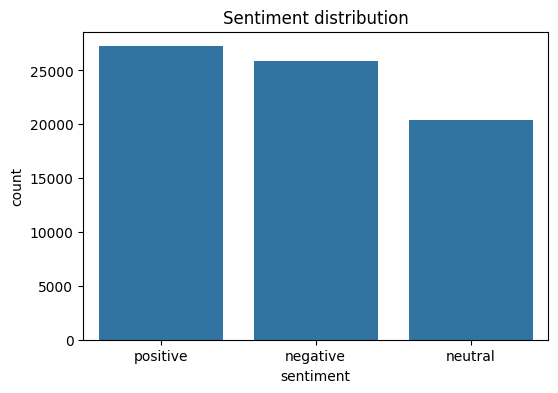

In [23]:
print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment distribution")
plt.show()

brand
ВкусВилл         994
Hyundai          567
Москвич          546
СберЗдоровье     546
Мать и дитя      534
                ... 
Промсвязьбанк    317
Тинькофф         310
Сбербанк         308
Почта Банк       303
Ренессанс        280
Name: count, Length: 154, dtype: int64


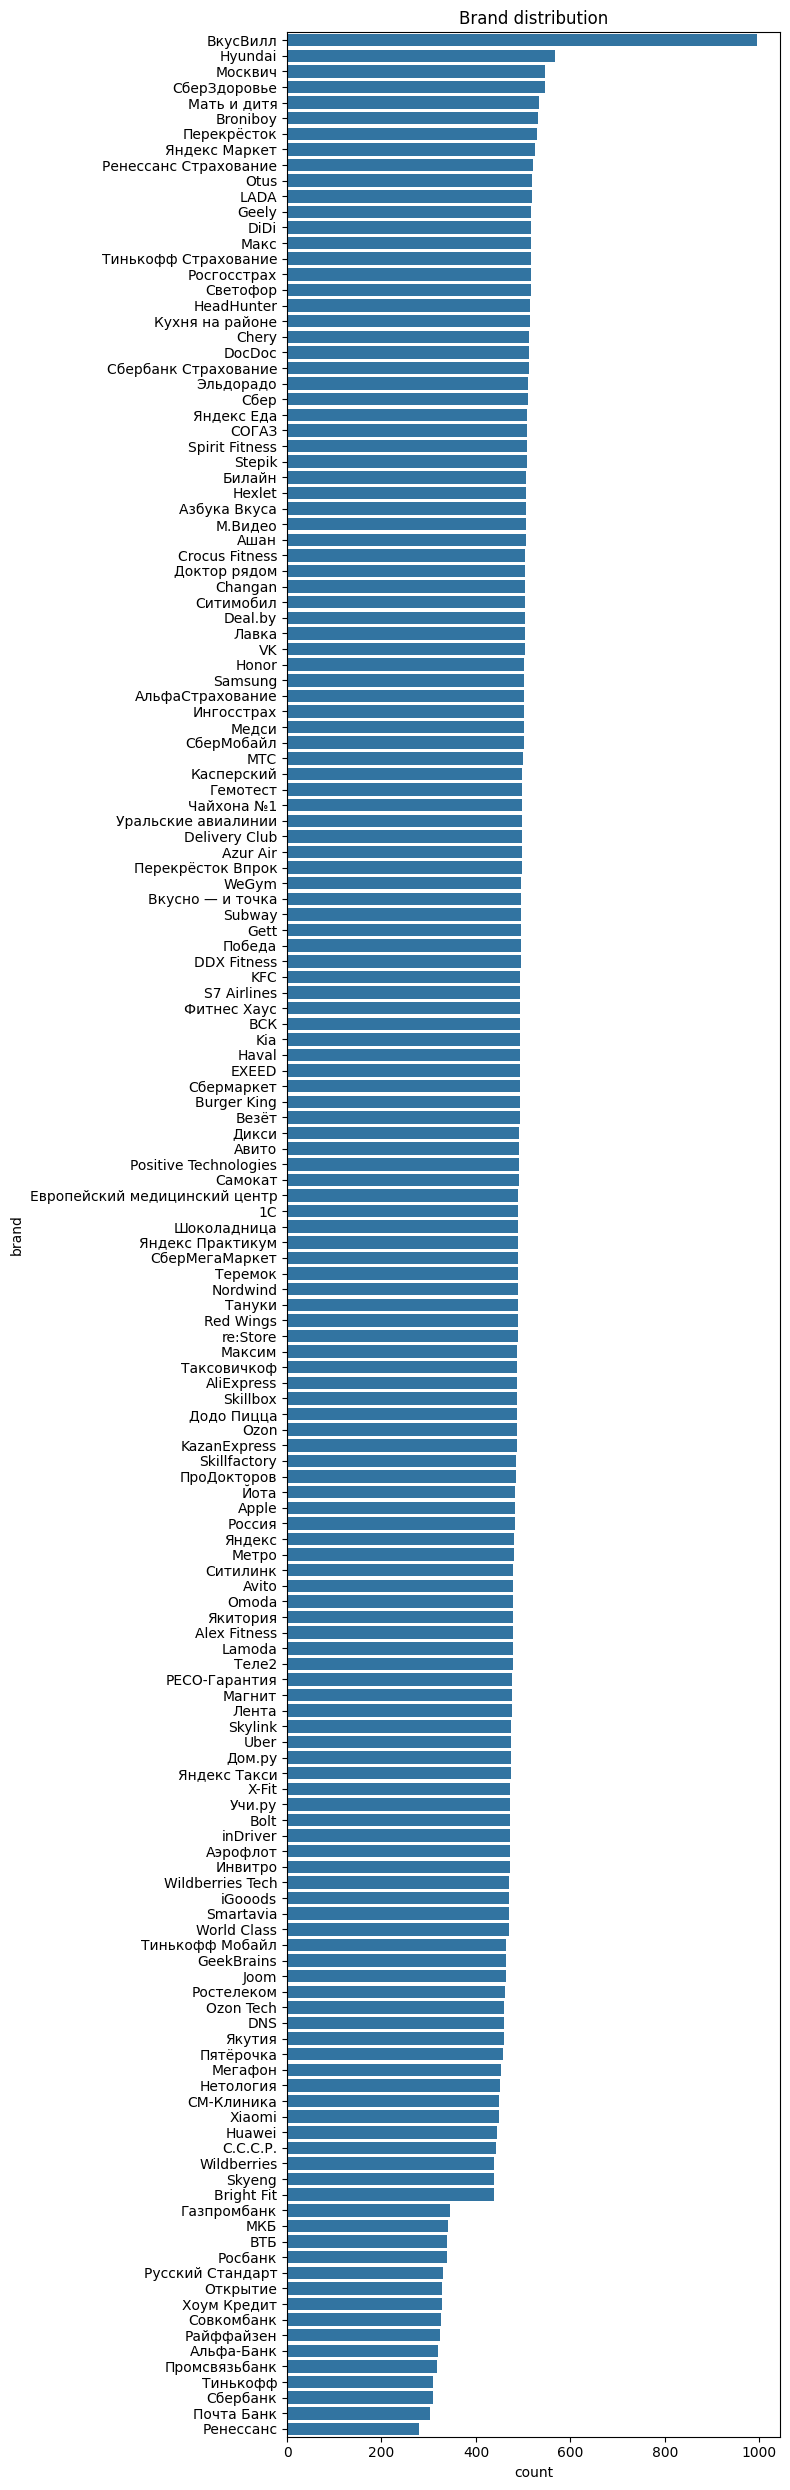

In [24]:
print(df["brand"].value_counts())

plt.figure(figsize=(8,25))
sns.countplot(data=df, y="brand",
              order=df["brand"].value_counts().index)
plt.title("Brand distribution")
plt.tight_layout()
plt.show()

           char_len    word_count
count  73549.000000  73549.000000
mean     626.714503     97.431168
std      232.645860     35.776252
min      216.000000     35.000000
25%      417.000000     65.000000
50%      616.000000     97.000000
75%      767.000000    118.000000
max     1352.000000    199.000000


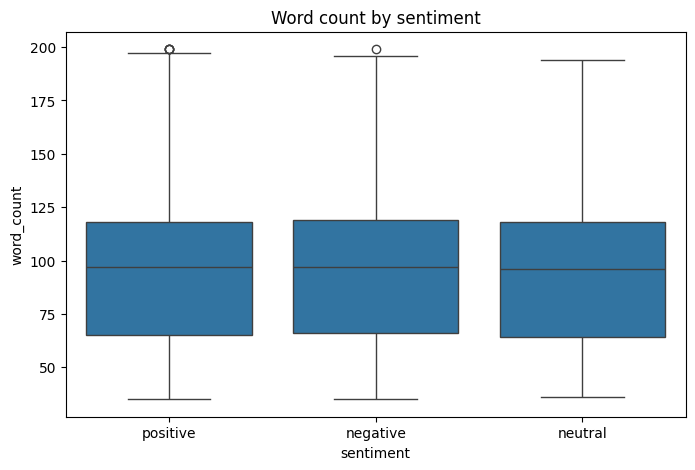

In [25]:
df["char_len"] = df["text"].str.len()
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print(df[["char_len", "word_count"]].describe())

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="sentiment", y="word_count")
plt.title("Word count by sentiment")
plt.show()

In [30]:
positive = df[df["sentiment"] == "positive"]["word_count"]
neutral = df[df["sentiment"] == "neutral"]["word_count"]
negative = df[df["sentiment"] == "negative"]["word_count"]

stat, p = stats.kruskal(positive, neutral, negative)
print(f"Kruskal-Wallis H-statistic: {stat:.3f}, p-value: {p:.3f}")
if p > 0.05:
    print("Нет статистически значимой разницы между группами.")
else:
    print("Есть статистически значимая разница между группами.")


Kruskal-Wallis H-statistic: 20.346, p-value: 0.000
Есть статистически значимая разница между группами.


In [32]:
def cohens_d(group1, group2):
    mean_diff = np.mean(group1) - np.mean(group2)
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    d = mean_diff / pooled_std
    return d

print(f"Cohen's d for positive and neutral: {cohens_d(positive, neutral):.3f}")
print(f"Cohen's d for positive and negative: {cohens_d(positive, negative):.3f}")
print(f"Cohen's d for neutral and negative: {cohens_d(neutral, negative):.3f}")

Cohen's d for positive and neutral: 0.022
Cohen's d for positive and negative: -0.012
Cohen's d for neutral and negative: -0.034
